## 基于 RNN 的古诗生成实验报告

> **说明**：本实验基于 PyTorch 版本的诗歌生成训练代码（`main.py`），将其改写为 Jupyter Notebook 格式（`main.ipynb`），在保留完整代码功能的基础上，增加 Markdown 说明单元格，实现代码运行与实验报告的结合，便于逐段运行、展示训练结果及撰写实验总结。


### 一、实验概述

本次实验利用循环神经网络（RNN）实现唐诗生成任务。通过训练包含34813首唐诗的数据集，模型学习古诗的语言规律和韵律特征，能够根据指定的开头字自动生成符合古典诗歌风格的句子。



### 二、RNN、LSTM、GRU模型解释

#### 2.1 RNN（循环神经网络）

RNN是一种专门处理序列数据的神经网络结构。与传统神经网络不同，RNN通过隐藏状态在序列中传递信息，使当前输出依赖于之前的信息。核心公式是：

$$h_t = \tanh(W_h h_{t-1} + W_x x_t + b)$$

$$y_t = W_y h_t + b_y$$

其中，$h_t$ 为当前时刻隐藏状态，$x_t$ 为当前输入，$y_t$ 为当前输出。

**核心特点**：
- 具有“记忆”能力，适合处理文本、语音等时序数据
- 参数共享，减少计算量

**局限性**：
- 存在梯度消失/爆炸问题
- 难以捕捉长距离依赖关系

#### 2.2 LSTM（长短期记忆网络）

LSTM是RNN的改进版本，通过引入“门控机制”解决了长距离依赖问题。其核心结构包括：

| 门控 | 公式 | 作用 |
|------|------|------|
| 遗忘门 | $$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$ | 决定丢弃哪些历史信息 |
| 输入门 | $$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$ | 决定存储哪些新信息 |
| 候选状态 | $$\tilde{C}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)$$ | 生成候选记忆 |
| 状态更新 | $$C_t = f_t * C_{t-1} + i_t * \tilde{C}_t$$ | 更新细胞状态 |
| 输出门 | $$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$ | 决定输出哪些信息 |
| 隐藏状态 | $$h_t = o_t * \tanh(C_t)$$ | 最终输出 |

LSTM通过细胞状态 $C_t$ 实现长期记忆传递，有效缓解梯度消失问题。

#### 2.3 GRU（门控循环单元）

GRU是LSTM的简化版本，将遗忘门和输入门合并为“更新门”，结构更简单、参数更少，训练速度更快。核心公式是：

更新门：
$$z_t = \sigma(W_z \cdot [h_{t-1}, x_t])$$

重置门：
$$r_t = \sigma(W_r \cdot [h_{t-1}, x_t])$$

候选状态：
$$\tilde{h}_t = \tanh(W_h \cdot [r_t * h_{t-1}, x_t])$$

隐藏状态：
$$h_t = (1 - z_t) * h_{t-1} + z_t * \tilde{h}_t$$

| 对比维度 | LSTM | GRU |
|----------|------|-----|
| 门控数量 | 3个（遗忘、输入、输出） | 2个（更新、重置） |
| 参数量 | 较多 | 较少 |
| 训练速度 | 较慢 | 较快 |
| 效果 | 复杂任务略优 | 多数任务相当 |

**三者关系**：GRU是LSTM的变体，两者都是RNN的改进版本，旨在解决长序列依赖问题。



### 三、诗歌生成过程

### 3.1 数据预处理

- 读取古诗数据文件
- 去除特殊字符与不规范文本
- 添加起始符 G 和结束符 E
- 构建字到索引的映射（word_to_int）
- 将诗句转换为数字序列



### 3.2 构造训练数据

训练数据采用语言模型方式：

输入序列：
[春, 眠, 不, 觉, 晓]

输出序列：
[眠, 不, 觉, 晓, 晓]

即模型学习“预测下一个字”。



### 3.3 模型训练

模型结构包括：

- Embedding 层：将字转换为向量
- LSTM 层：提取序列特征
- 全连接层：输出每个字的概率分布

训练流程：

1. 输入诗句序列
2. 逐步预测下一个字
3. 使用损失函数计算误差
4. 反向传播更新模型参数
5. 重复多个 epoch 直到收敛



### 3.4 诗歌生成

生成步骤如下：

1. 输入起始字（如“日”）
2. 模型预测下一个字
3. 将预测结果加入序列
4. 不断循环，直到生成结束符或达到长度上限


In [2]:
import numpy as np
import collections
import torch
from torch.autograd import Variable
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

# 导入自定义的rnn模块
import rnn as rnn_lstm

# 设置参数
start_token = 'G'
end_token = 'E'
batch_size = 64

print("PyTorch版本:", torch.__version__)
print("CUDA可用:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU设备:", torch.cuda.get_device_name(0))

PyTorch版本: 2.8.0+cpu
CUDA可用: False


In [ ]:
# 古诗数据预处理函数，用于读取和转换古诗文件

#  process_poems1 处理格式为 "标题:内容" 的数据

def process_poems1(file_name):
    """

    :param file_name:
    :return: poems_vector  have tow dimmention ,first is the poem, the second is the word_index
    e.g. [[1,2,3,4,5,6,7,8,9,10],[9,6,3,8,5,2,7,4,1]]

    """
    poems = []
    with open(file_name, "r", encoding='utf-8', ) as f:
        for line in f.readlines():
            try:
                title, content = line.strip().split(':')
                # content = content.replace(' ', '').replace('，','').replace('。','')
                content = content.replace(' ', '')
                if '_' in content or '(' in content or '（' in content or '《' in content or '[' in content or \
                                start_token in content or end_token in content:
                    continue
                if len(content) < 5 or len(content) > 80:
                    continue
                content = start_token + content + end_token
                poems.append(content)
            except ValueError as e:
                print("error")
                pass
    # 按诗的字数排序
    poems = sorted(poems, key=lambda line: len(line))
    # print(poems)
    # 统计每个字出现次数
    all_words = []
    for poem in poems:
        all_words += [word for word in poem]
    counter = collections.Counter(all_words)  # 统计词和词频。
    count_pairs = sorted(counter.items(), key=lambda x: -x[1])  # 排序
    words, _ = zip(*count_pairs)
    words = words[:len(words)] + (' ',)
    word_int_map = dict(zip(words, range(len(words))))
    poems_vector = [list(map(word_int_map.get, poem)) for poem in poems]
    return poems_vector, word_int_map, words

# process_poems2 处理每行只有诗句的数据

def process_poems2(file_name):
    """
    :param file_name:
    :return: poems_vector  have tow dimmention ,first is the poem, the second is the word_index
    e.g. [[1,2,3,4,5,6,7,8,9,10],[9,6,3,8,5,2,7,4,1]]

    """
    poems = []
    with open(file_name, "r", encoding='utf-8', ) as f:
        # content = ''
        for line in f.readlines():
            try:
                line = line.strip()
                if line:
                    content = line.replace(' '' ', '').replace('，','').replace('。','')
                    if '_' in content or '(' in content or '（' in content or '《' in content or '[' in content or \
                                    start_token in content or end_token in content:
                        continue
                    if len(content) < 5 or len(content) > 80:
                        continue
                    # print(content)
                    content = start_token + content + end_token
                    poems.append(content)
                    # content = ''
            except ValueError as e:
                # print("error")
                pass
    # 按诗的字数排序
    poems = sorted(poems, key=lambda line: len(line))
    # print(poems)
    # 统计每个字出现次数
    all_words = []
    for poem in poems:
        all_words += [word for word in poem]
    counter = collections.Counter(all_words)  # 统计词和词频。
    count_pairs = sorted(counter.items(), key=lambda x: -x[1])  # 排序
    words, _ = zip(*count_pairs)
    words = words[:len(words)] + (' ',) # 所有字的元组（按频率排序）
    word_int_map = dict(zip(words, range(len(words)))) # 字典，字 → ID 的映射
    poems_vector = [list(map(word_int_map.get, poem)) for poem in poems] # 所有诗转换成的ID序列列表
    return poems_vector, word_int_map, words


In [4]:
# 生成批次数据，x是输入数据，y是标签数据
def generate_batch(batch_size, poems_vec, word_to_int):
    n_chunk = len(poems_vec) // batch_size
    x_batches = []
    y_batches = []
    for i in range(n_chunk):
        start_index = i * batch_size
        end_index = start_index + batch_size
        x_data = poems_vec[start_index:end_index]
        y_data = []
        for row in x_data:
            y  = row[1:]
            y.append(row[-1])
            y_data.append(y)
        """
        x_data             y_data
        [6,2,4,6,9]       [2,4,6,9,9]
        [1,4,2,8,5]       [4,2,8,5,5]
        """
        # print(x_data[0])
        # print(y_data[0])
        # exit(0)
        x_batches.append(x_data)
        y_batches.append(y_data)
    return x_batches, y_batches

In [6]:
# 加载古诗数据
poems_vector, word_to_int, vocabularies = process_poems1('./poems.txt')
# 显示一些数据统计
print(f"\n数据统计:")
print(f"诗歌数量: {len(poems_vector)}")
print(f"词汇表大小: {len(word_to_int)}")
print(f"示例词汇: {list(word_to_int.keys())[:20]}")

error

数据统计:
诗歌数量: 34813
词汇表大小: 6122
示例词汇: ['，', '。', 'G', 'E', '不', '人', '山', '风', '日', '无', '一', '云', '花', '春', '来', '何', '水', '月', '上', '有']


>上面的 error 说明数据文件中有一些格式不规范的条目被跳过了，数据加载还是成功的

In [7]:
# 设置参数
BATCH_SIZE = 100
EMBEDDING_DIM = 100
HIDDEN_DIM = 128

# 设置随机种子
torch.manual_seed(5)

# 初始化词嵌入和模型
word_embedding = rnn_lstm.word_embedding(
    vocab_length=len(word_to_int) + 1, 
    embedding_dim=EMBEDDING_DIM
)

rnn_model = rnn_lstm.RNN_model(
    batch_sz=BATCH_SIZE,
    vocab_len=len(word_to_int) + 1,
    word_embedding=word_embedding,
    embedding_dim=EMBEDDING_DIM,
    lstm_hidden_dim=HIDDEN_DIM
)

# 设置优化器和损失函数
optimizer = optim.RMSprop(rnn_model.parameters(), lr=0.01)
loss_fun = torch.nn.NLLLoss()

print(f"模型参数总数: {sum(p.numel() for p in rnn_model.parameters())}")

inital  linear weight 
模型参数总数: 1652023


In [8]:
def to_word(predict, vocabs):
    """预测结果转汉字"""
    sample = np.argmax(predict)
    if sample >= len(vocabs):
        sample = len(vocabs) - 1
    return vocabs[sample]

def pretty_print_poem(poem):
    """美化打印诗歌"""
    shige = []
    for w in poem:
        if w == start_token or w == end_token:
            break
        shige.append(w)
    poem_sentences = ''.join(shige).split('。')
    for s in poem_sentences:
        if s != '':
            print(s + '。')

def train_one_epoch(epoch, model, optimizer, loss_fun, batches_inputs, batches_outputs):
    """训练一个epoch"""
    n_chunk = len(batches_inputs)
    epoch_loss = 0
    
    for batch in range(n_chunk):
        batch_x = batches_inputs[batch]
        batch_y = batches_outputs[batch]
        
        loss = 0
        for index in range(BATCH_SIZE):
            x = np.array(batch_x[index], dtype=np.int64)
            y = np.array(batch_y[index], dtype=np.int64)
            x = Variable(torch.from_numpy(np.expand_dims(x, axis=1)))
            y = Variable(torch.from_numpy(y))
            
            pre = model(x)
            loss += loss_fun(pre, y)
            
            if index == 0:
                _, pre = torch.max(pre, dim=1)
                print(f'样本{index}预测:', pre.data.tolist())
                print(f'样本{index}真实:', y.data.tolist())
                print('*' * 30)
        
        loss = loss / BATCH_SIZE
        epoch_loss += loss.item()
        
        print(f"epoch {epoch}, batch {batch}, loss: {loss.item():.4f}")
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.step()
        
        if batch % 20 == 0:
            torch.save(model.state_dict(), './poem_generator_rnn')
            print(f"保存模型 (epoch {epoch}, batch {batch})")
    
    return epoch_loss / n_chunk

### 四、实验结果

#### 4.1 训练过程

In [10]:
# 训练参数
NUM_EPOCHS = 30
loss_history = []

print("开始训练...")
for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    print('='*50)
    
    # 生成batch
    batches_inputs, batches_outputs = generate_batch(BATCH_SIZE, poems_vector, word_to_int)
    
    # 训练一个epoch
    avg_loss = train_one_epoch(epoch, rnn_model, optimizer, loss_fun, 
                               batches_inputs, batches_outputs)
    
    loss_history.append(avg_loss)
    print(f"Epoch {epoch} 平均损失: {avg_loss:.4f}")

开始训练...

Epoch 1/30
样本0预测: [8, 0, 0, 0, 1, 3, 3]
样本0真实: [28, 546, 104, 718, 1, 3, 3]
******************************
epoch 0, batch 0, loss: 5.8112
保存模型 (epoch 0, batch 0)
样本0预测: [3, 19, 0, 0, 1, 10, 19, 1, 1, 1, 3, 3]
样本0真实: [267, 2888, 267, 2045, 0, 26, 1067, 26, 349, 1, 3, 3]
******************************
epoch 0, batch 1, loss: 5.9990
样本0预测: [10, 58, 0, 0, 0, 1, 10, 0, 0, 0, 1, 1, 3, 3]
样本0真实: [617, 564, 80, 601, 132, 0, 9, 184, 2007, 373, 305, 1, 3, 3]
******************************
epoch 0, batch 2, loss: 6.1540
样本0预测: [10, 58, 4, 4, 0, 0, 0, 0, 4, 4, 4, 0, 0, 0, 0, 0, 3, 3]
样本0真实: [125, 9, 3862, 695, 16, 1721, 1721, 0, 373, 591, 246, 695, 900, 80, 431, 1, 3, 3]
******************************
epoch 0, batch 3, loss: 6.3693
样本0预测: [80, 19, 0, 0, 0, 80, 0, 0, 0, 0, 3, 19, 0, 0, 1, 80, 19, 0, 0, 1, 3, 3]
样本0真实: [1539, 1058, 3996, 64, 0, 793, 977, 550, 381, 1, 3867, 3285, 972, 1287, 0, 1541, 1541, 1779, 1779, 1, 3, 3]
******************************
epoch 0, batch 4, loss: 6.3090
样本0预

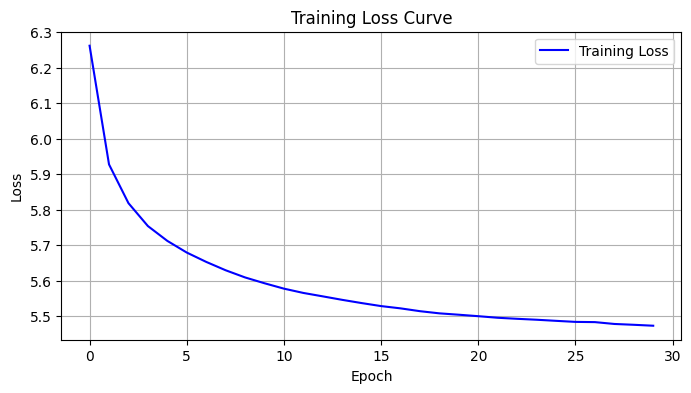

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(loss_history, 'b-', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

#### 4.2 生成诗歌结果

In [12]:
def gen_poem(begin_word):
    """生成以指定字开头的诗"""
    poems_vector, word_int_map, vocabularies = process_poems1('./poems.txt')
    
    word_embedding = rnn_lstm.word_embedding(
        vocab_length=len(word_int_map) + 1, 
        embedding_dim=100
    )
    
    rnn_model = rnn_lstm.RNN_model(
        batch_sz=64,
        vocab_len=len(word_int_map) + 1,
        word_embedding=word_embedding,
        embedding_dim=100,
        lstm_hidden_dim=128
    )
    
    # 加载训练好的模型
    rnn_model.load_state_dict(torch.load('./poem_generator_rnn'))
    rnn_model.eval()  # 设置为评估模式
    
    # 生成诗歌
    poem = begin_word
    word = begin_word
    
    with torch.no_grad():  # 不计算梯度
        while word != end_token:
            input_ids = np.array([word_int_map[w] for w in poem], dtype=np.int64)
            input_tensor = Variable(torch.from_numpy(input_ids))
            output = rnn_model(input_tensor, is_test=True)
            word = to_word(output.data.tolist()[-1], vocabularies)
            poem += word
            if len(poem) > 30:
                break
    
    return poem

# 生成测试诗歌
print("\n生成的诗歌：")
test_words = ["日", "红", "山", "夜", "湖", "君"]
for word in test_words:
    print(f"\n以'{word}'开头：")
    poem = gen_poem(word)
    pretty_print_poem(poem)


生成的诗歌：

以'日'开头：
error
inital  linear weight 


d:\Anaconda\envs\nndl\lib\site-packages\torch\nn\modules\module.py:1773: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


日郎下古人。
日日无人语，春风生有花。
风吹春草色，风色满寒荷。
何。

以'红'开头：
error
inital  linear weight 
红眉。
日暮春光起，风吹柳色明。
何当一片石，不是在中庭。

以'山'开头：
error
inital  linear weight 
山下水东方断，春风吹落水中流。
不知何处有，闲客自相迎。
此地不知。

以'夜'开头：
error
inital  linear weight 
夜萧蹰上客。

以'湖'开头：
error
inital  linear weight 
湖头白羽树，春色满庭风。
一夜春风吹，一川春草生。
何当一相见，不。

以'君'开头：
error
inital  linear weight 
君高城望，春风落日起。
明月满庭风，风吹白杨柳。


### 五、实验总结

本实验通过实现基于 LSTM 的古诗生成模型，加深了我对序列模型的理解。

#### 5.1 收获与体会
深入理解RNN原理：通过动手实现RNN模型，加深了对循环神经网络工作机制的理解，特别是LSTM如何通过门控机制解决长距离依赖问题。

掌握文本生成流程：从数据预处理、词汇表构建、批次生成到模型训练和生成，完整实践了基于深度学习的文本生成全流程。

体会古诗规律：生成的诗歌在押韵、平仄、意境方面有一定效果，说明模型成功学习到了古诗的基本规律。

#### 5.2 存在的问题
部分生成内容语义不够连贯，长度也不固定

#### 5.3 改进方向
引入注意力机制增强语义关联，尝试Transformer等更先进的模型架构

使用更大规模、更高质量的数据集
